### Digitalisierung von Bildern

Die **Farbtiefe** ist der Speicherplatz, der benötigt wird, um die Farbinformation für ein Pixel zu speichern. Eine Farbtiefe von 3 Bit bedeutet, dass 3 Bit Speicherplatz je Pixel zur Verfügung steht. Damit können $2^3 = 8$ verschiedene Farben dargestellt werden.

Für die Angabe der **Bildauflösung** gibt es verschiedene Möglichkeiten:
- Gesamtzahl aller Pixel, z.B: Das Bild hat eine Auflösung von 8 Megapixel
- Pixel-Anzahl für Länge mal Breite, z.B: Full HD = Auflösung von 1920 x 1080 Pixel 

Wenn jedes Pixel eines Bildes binär codiert wird, ist die **Datenmenge** eines Bildes das Produkt aus Anzahl Pixel und Farbtiefe.

Bei der **Datenkompression** (auch: Datenkomprimierung) wird die Menge an Daten reduziert, also verringert. Wenn die Verringerung der Datenmenge mit einem Qualitätsverlust einher geht, spricht man von verlustbehafteter Datenkompression, ansonsten von verlustfreier Kompression. Dabei ist es unwesentlich, ob der Qualitätsverlust wahrnehmbar ist oder nicht. 

#### RGB

Beim RGB-System setzt sich jede Farbe zusammen aus Anteilen von Rot, Grün und Blau. Die Anteile werden häufig mit Werten von 0-255 angegeben. Damit ergibt sich eine Farbtiefe von 24 Bit und die Möglichkeit, 16_777_216 Farben zu codieren.

[Adobe Color](https://color.adobe.com/de/)

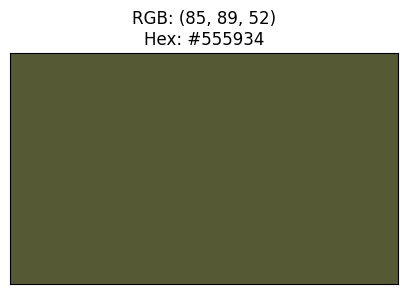

In [8]:
import matplotlib.pyplot as plt

# RGB Werte
r = 85  # Rot (0-255)
g = 89  # Grün (0-255)
b = 52   # Blau (0-255)

# Ein einfacher Plot
plt.figure(figsize=(5, 3))
plt.axhspan(0, 1, color=[r/255,g/255,b/255])  # plot mit Farbe füllen

# Achsen und Ränder entfernen
plt.xticks([])
plt.yticks([])
plt.margins(0)

# RGB und Hex Werte als Text hinzufügen
hex_color = f'#{r:02X}{g:02X}{b:02X}'
plt.title(f'RGB: ({r}, {g}, {b})\nHex: {hex_color}')

plt.show()

#### Lauflängenkodierung (RLE, run-length encoding)

Idee: Statt jedes einzelne Bit/Zeichen zu speichern, zählt man, wie oft derselbe Wert **direkt hintereinander** vorkommt, und speichert nur *(Wert, Anzahl)*-Paare. Das funktioniert verlustfrei — beim Entpacken entsteht exakt die Ausgangsfolge zurück.

```
    Bitfolge: 0000111111000001111100000
    RLE-Code: (0,4) (1,6) (0,5) (1,5) (0,5)
```


Für Bilder bedeutet dies: Statt für jedes Pixel die Farbe zu notieren, wird die Farbe zusammen mit der Anzahl der Pixel, die diese Farbe haben, notiert. Falls es nur zwei Farben gibt, kann die Nennung der Farbe weggelassen werden. Dann muss aber vereinbart werden, welches die Start-Farbe ist.

 
Beispiel: Ein schwarz-weiß Bild ist 8 Pixel breit und 7 Pixel hoch. Die Start-Farbe ist schwarz. Codierung:

    9 6 2 1 1 2 1 1 2 6 1 4 1 2 6 9

<img src='bilder/bild6.png' width='300'>

### Digitalisierung von Audio


Töne werden als Schwingungslinie dargestellt. Je größer die **Amplitude**, desto lauter der Ton. Je enger die Schwingungslinie, 
desto höher der Ton. Sprache und Musik erzeugen kompliziertere Schwingungslinien als einzelne Töne. Die Schwingungslinie nennt man auch **Signal**. Die **Samplingrate** (oder **Abtastrate**) gibt an, wie oft das Signal in einer Sekunde abgetastet wird.

<img src='bilder/audio1.png'>

 Eine übliche Abtastrate beträgt 44.1 kHz, das Signal wird also 44100 mal pro Sekunde abgetastet. Die gemessenen Signalwerte müssen geeignet gerundet werden, um sie speichern zu können. Die **Samplingtiefe** gibt den Speicherplatz an, der für die verschiedenen Signalstärken zur Verfügung stehen. Bei einer üblichen Samplingtiefe von 16 Bit stehen für jeden gemessenen Wert 16 Bit zur Verfügung, damit sind $2^{16} = 65536$ verschiedene Signalstärken möglich. **Datenrate** nennt man die Datenmenge (in Bit), die in einer Sekunde entsteht. Es gilt: Datenrate = Samplingtiefe * Samplingrate. Die **Datenmenge** ist die Datenmenge, die insgesamt entsteht.

#### Beispiel

Im Beispiel wird das Signal 12 mal pro Sekunde abgetastet. Die Samplingrate beträgt also 12 Hz. Zur Unterscheidung der Signalstärke stehen 8 verschiedene Werte zur Verfügung. Die Samplingtiefe ist also 3. Die Datenrate ist 36 Bit/s.

<img src='bilder/audio.png' width='500'>

Die Audiodatei enthält folgende Nutzdaten (die Leerstellen sind zur Lesbarkeit eingefügt):

    000 111 110 100 100 000 001 010 110 100 010 001

Damit die Daten richtig interpretiert werden können, müssen in die Audiodatei noch Steuerdaten eingefügt werden:

    Wortbreite = 3
    Dauer = 1 
    tiefster Wert = -3

### Verlustbehaftete vs. verlustfreie Kompression


| Format / Anwendung       | Art             | Begründung                                                       |
| ------------------------ | --------------- | ---------------------------------------------------------------- |
| MP3 (Musik)              | verlustbehaftet | Für das Gehör kaum wahrnehmbare Frequenzanteile werden entfernt. |
| JPEG (Foto)              | verlustbehaftet | Kompromiss zwischen Dateigröße und Bildqualität.                 |
| PNG (Grafik, Screenshot) | verlustfrei     | Bilddaten müssen pixelgenau erhalten bleiben.                    |
| ZIP (Programmcode, Text) | verlustfrei     | Nach dem Entpacken muss exakt der Originaltext/-code vorliegen.  |

Programmcode und Textdokumente müssen *bit-genau* erhalten bleiben — schon ein verändertes Zeichen (z. B. ein Semikolon) kann Code unbrauchbar machen oder die Bedeutung eines Textes verändern. Bei Video und Musik nimmt der Mensch kleine Abweichungen dagegen kaum wahr, sodass zugunsten einer viel kleineren Datei ein geringer Qualitätsverlust akzeptiert wird — etwa beim Video-Streaming (begrenzte Bandbreite) oder bei Videotelefonie (Echtzeitübertragung, geringe Latenz wichtiger als volle Qualität).

 
